<a href="https://colab.research.google.com/github/AarnavSawant/KVCompass/blob/main/KVCompass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/AarnavSawant/KVCompass/blob/main/KVCompass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KVCompass Benchmark Team Notebook

This notebook is organized around the **core benchmark matrix**: RULER task category x method x budget x context length. Each teammate should run only their labeled section, then Aarnav can use the final aggregation cells to combine the benchmark summaries for the presentation.


## Shared Experiment Plan

**Benchmark**
- `RULER`
- `fraction: 0.02`
- context lengths: `4096`, `8192`

**Task categories**
- Needle In A Haystack: `niah`
- Question Answering: `qa`
- Multi-Hop Tracing: `vt`
- Aggregation: `cwe`, `fwe`

**Methods in the core matrix**
- `no_compression @ 1.0`
- `snapkv @ 0.5`
- `expected_attention @ 0.5`
- `knorm @ 0.5`
- `tova @ 0.5`
- `streaming_llm @ 0.5`

**Team split**
- Tony: `niah` compressed-method runs at `4096` and `8192`
- Will: `qa` compressed-method runs at `4096` and `8192`
- Grady: `vt` compressed-method runs at `4096` and `8192`
- Jamez: all `no_compression` baselines across all categories and both context lengths
- Aarnav: `aggregation` compressed-method runs at `4096` and `8192`, plus final aggregation

**Core matrix size**
- `40` total benchmark runs
- `32` compressed-method runs across the four category owners
- `8` baseline runs for Jamez


In [2]:
# Shared setup: clone/refresh the repo, switch to the demo branch, mount Drive, and install dependencies.
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

BRANCH_NAME = 'main'
repo_dir = Path('/content/KVCompass')
if not repo_dir.exists():
    !git clone https://github.com/AarnavSawant/KVCompass.git /content/KVCompass

%cd /content/KVCompass
!git fetch origin
!git checkout "$BRANCH_NAME"
!git pull origin "$BRANCH_NAME"
!nvidia-smi
!python -m pip install --upgrade pip
!pip install -r requirements.txt
!pip install -e .


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/KVCompass
Already on 'main'
Your branch is up to date with 'origin/main'.
From https://github.com/AarnavSawant/KVCompass
 * branch            main       -> FETCH_HEAD
Already up to date.
/bin/bash: line 1: nvidia-smi: command not found
Obtaining file:///content/KVCompass
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for kvpress-eval (pyproject.toml) ... done
  Created wheel for kvpress-eval: filename=kvpress_eval-0.1.0-0.editable-py3-none-any.whl size=1368 sha256=585a8df9e92f941ef4bbd3765c8a7f3c6cebd82deb230445f97a8925cbf40889
  Stored in directory: /tmp/pip-ephem-wheel-cache-klpcw7ot/wheels/ee/77/11/2be5044f515844becbd2dc24e3f88efbf0b772ea8d9645e070
Successfully built kv

In [3]:
# Shared auth: set HF_TOKEN from Colab secrets and verify the login.
from google.colab import userdata
from huggingface_hub import whoami
import os

os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
print(whoami())


{'type': 'user', 'id': '698bae6460ced7ae85940438', 'name': 'asawant39', 'fullname': 'Aarnav Sawant', 'email': 'asawant39@gatech.edu', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1777593600, 'isPro': False, 'avatarUrl': '/avatars/8c56beb2f271fd138386f6fc9d95e039.svg', 'orgs': [{'type': 'org', 'id': '64155eaa95fb6f824b237c3d', 'name': 'GeorgiaTech', 'fullname': 'Georgia Institute of Technology', 'email': None, 'canPay': False, 'billingMode': 'postpaid', 'periodEnd': None, 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/64155e8abe60230f2f40b03a/3i-AL3LrNkaTarSKnaGy8.png', 'roleInOrg': 'contributor'}], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'Colab', 'role': 'write', 'createdAt': '2026-04-08T19:38:24.894Z'}}}


In [4]:
# Shared values used by all run cells.
from pathlib import Path

MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'
FRACTION = 0.1
TORCH_DTYPE = 'bfloat16'
SHARED_RESULTS_DIR = Path('/content/drive/MyDrive/KVCompass')
SHARED_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print('Shared results dir:', SHARED_RESULTS_DIR)


Shared results dir: /content/drive/MyDrive/KVCompass


## Tony: Needle In A Haystack

Run the next two cells only. This assignment covers the benchmark-backed `niah` slice for the compressed methods at `4096` and `8192`.


In [5]:
# Write the sweep config for Assignment 1.
from pathlib import Path

config_text = f"""
sweep:
  name: assignment_1
  model: {MODEL_NAME}
  device: auto
  torch_dtype: {TORCH_DTYPE}
  methods_config_path: configs/methods.yaml
  output_dir: {SHARED_RESULTS_DIR.as_posix()}/benchmark_eval
  seed: 42
  verbose: false
  scenarios:
    - name: needle_in_a_haystack_4k
      dataset: ruler
      data_dir: "4096"
      task_prefixes: ["niah"]
      fraction: {FRACTION}
      methods:
        - snapkv
        - expected_attention
        - knorm
        - tova
        - streaming_llm
      budgets:
        default: [0.5]
    - name: needle_in_a_haystack_8k
      dataset: ruler
      data_dir: "8192"
      task_prefixes: ["niah"]
      fraction: {FRACTION}
      methods:
        - snapkv
        - expected_attention
        - knorm
        - tova
        - streaming_llm
      budgets:
        default: [0.5]
"""
Path('configs/benchmark_sweeps.assignment_1.yaml').write_text(config_text, encoding='utf-8')
print(Path('configs/benchmark_sweeps.assignment_1.yaml').read_text())



sweep:
  name: assignment_1
  model: Qwen/Qwen2.5-1.5B-Instruct
  device: auto
  torch_dtype: bfloat16
  methods_config_path: configs/methods.yaml
  output_dir: /content/drive/MyDrive/KVCompass/benchmark_eval
  seed: 42
  verbose: false
  scenarios:
    - name: needle_in_a_haystack_4k
      dataset: ruler
      data_dir: "4096"
      task_prefixes: ["niah"]
      fraction: 0.1
      methods:
        - snapkv
        - expected_attention
        - knorm
        - tova
        - streaming_llm
      budgets:
        default: [0.5]
    - name: needle_in_a_haystack_8k
      dataset: ruler
      data_dir: "8192"
      task_prefixes: ["niah"]
      fraction: 0.1
      methods:
        - snapkv
        - expected_attention
        - knorm
        - tova
        - streaming_llm
      budgets:
        default: [0.5]



In [ ]:
# Run Assignment 1.
!python scripts/run_kvpress_benchmark_sweep.py --config configs/benchmark_sweeps.assignment_1.yaml


## Will: Question Answering

Run the next two cells only. This assignment covers the benchmark-backed `qa` slice for the compressed methods at `4096` and `8192`.


In [6]:
# Write the sweep config for Assignment 2.
from pathlib import Path

config_text = f"""
sweep:
  name: assignment_2
  model: {MODEL_NAME}
  device: auto
  torch_dtype: {TORCH_DTYPE}
  methods_config_path: configs/methods.yaml
  output_dir: {SHARED_RESULTS_DIR.as_posix()}/benchmark_eval
  seed: 42
  verbose: false
  scenarios:
    - name: question_answering_4k
      dataset: ruler
      data_dir: "4096"
      task_prefixes: ["qa"]
      fraction: {FRACTION}
      methods:
        - snapkv
        - expected_attention
        - knorm
        - tova
        - streaming_llm
      budgets:
        default: [0.5]
    - name: question_answering_8k
      dataset: ruler
      data_dir: "8192"
      task_prefixes: ["qa"]
      fraction: {FRACTION}
      methods:
        - snapkv
        - expected_attention
        - knorm
        - tova
        - streaming_llm
      budgets:
        default: [0.5]
"""
Path('configs/benchmark_sweeps.assignment_2.yaml').write_text(config_text, encoding='utf-8')
print(Path('configs/benchmark_sweeps.assignment_2.yaml').read_text())



sweep:
  name: assignment_2
  model: Qwen/Qwen2.5-1.5B-Instruct
  device: auto
  torch_dtype: bfloat16
  methods_config_path: configs/methods.yaml
  output_dir: /content/drive/MyDrive/KVCompass/benchmark_eval
  seed: 42
  verbose: false
  scenarios:
    - name: question_answering_4k
      dataset: ruler
      data_dir: "4096"
      task_prefixes: ["qa"]
      fraction: 0.1
      methods:
        - snapkv
        - expected_attention
        - knorm
        - tova
        - streaming_llm
      budgets:
        default: [0.5]
    - name: question_answering_8k
      dataset: ruler
      data_dir: "8192"
      task_prefixes: ["qa"]
      fraction: 0.1
      methods:
        - snapkv
        - expected_attention
        - knorm
        - tova
        - streaming_llm
      budgets:
        default: [0.5]



In [ ]:
# Run Assignment 2.
!python scripts/run_kvpress_benchmark_sweep.py --config configs/benchmark_sweeps.assignment_2.yaml


## Grady: Multi-Hop Tracing

Run the next two cells only. This assignment covers the benchmark-backed `vt` slice for the compressed methods at `4096` and `8192`.


In [ ]:
# Write the sweep config for Assignment 3.
from pathlib import Path

config_text = f"""
sweep:
  name: assignment_3
  model: {MODEL_NAME}
  device: auto
  torch_dtype: {TORCH_DTYPE}
  methods_config_path: configs/methods.yaml
  output_dir: {SHARED_RESULTS_DIR.as_posix()}/benchmark_eval
  seed: 42
  verbose: false
  scenarios:
    - name: multi_hop_tracing_4k
      dataset: ruler
      data_dir: "4096"
      task_prefixes: ["vt"]
      fraction: {FRACTION}
      methods:
        - snapkv
        - expected_attention
        - knorm
        - tova
        - streaming_llm
      budgets:
        default: [0.5]
    - name: multi_hop_tracing_8k
      dataset: ruler
      data_dir: "8192"
      task_prefixes: ["vt"]
      fraction: {FRACTION}
      methods:
        - snapkv
        - expected_attention
        - knorm
        - tova
        - streaming_llm
      budgets:
        default: [0.5]
"""
Path('configs/benchmark_sweeps.assignment_3.yaml').write_text(config_text, encoding='utf-8')
print(Path('configs/benchmark_sweeps.assignment_3.yaml').read_text())


In [ ]:
# Run Assignment 3.
!python scripts/run_kvpress_benchmark_sweep.py --config configs/benchmark_sweeps.assignment_3.yaml


## Jamez: No Compression Baselines

Run the next two cells only. This assignment covers the `no_compression` baselines across all four categories and both context lengths.


In [5]:
# Write the sweep config for Assignment 4.
from pathlib import Path

config_text = f"""
sweep:
  name: assignment_4
  model: {MODEL_NAME}
  device: auto
  torch_dtype: {TORCH_DTYPE}
  methods_config_path: configs/methods.yaml
  output_dir: {SHARED_RESULTS_DIR.as_posix()}/benchmark_eval
  seed: 42
  verbose: false
  scenarios:
    - name: aggregation_4k_baseline
      dataset: ruler
      data_dir: "4096"
      task_prefixes: ["cwe", "fwe"]
      fraction: {FRACTION}
      methods: [no_compression]
      budgets:
        no_compression: [1.0]
"""
Path('configs/benchmark_sweeps.assignment_4.yaml').write_text(config_text, encoding='utf-8')
print(Path('configs/benchmark_sweeps.assignment_4.yaml').read_text())



sweep:
  name: assignment_4
  model: Qwen/Qwen2.5-1.5B-Instruct
  device: auto
  torch_dtype: bfloat16
  methods_config_path: configs/methods.yaml
  output_dir: /content/drive/MyDrive/KVCompass/benchmark_eval
  seed: 42
  verbose: false
  scenarios:
    - name: aggregation_4k_baseline
      dataset: ruler
      data_dir: "4096"
      task_prefixes: ["cwe", "fwe"]
      fraction: 0.1
      methods: [no_compression]
      budgets:
        no_compression: [1.0]



In [6]:
# Run Assignment 4.
!python scripts/run_kvpress_benchmark_sweep.py --config configs/benchmark_sweeps.assignment_4.yaml


2026-04-15 04:05:14,753 | INFO | kvpress_eval.compat | Applied KVPress compatibility patch for missing cache_position support.
2026-04-15 04:05:14,758 | INFO | kvpress_eval.runner | Loading model Qwen/Qwen2.5-1.5B-Instruct
2026-04-15 04:05:15,043 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 04:05:15,054 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-1.5B-Instruct/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/config.json "HTTP/1.1 200 OK"
2026-04-15 04:05:15,067 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-1.5B-Instruct/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/config.json "HTTP/1.1 200 OK"
config.json: 100% 660/660 [00:00<00:00, 3.88MB/s]
2026-04-15 04:05:15,174 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct/resolve/main/tokenizer_config.json "H

## Aarnav: Aggregation And Final Aggregation

Run the next two cells for the benchmark-backed `cwe, fwe` aggregation slice for the compressed methods at `4096` and `8192`. Then use the final aggregation cells after everyone has shared their outputs.


In [7]:
# Write the sweep config for Assignment 5.
from pathlib import Path

config_text = f"""
sweep:
  name: assignment_5
  model: {MODEL_NAME}
  device: auto
  torch_dtype: {TORCH_DTYPE}
  methods_config_path: configs/methods.yaml
  output_dir: {SHARED_RESULTS_DIR.as_posix()}/benchmark_eval
  seed: 42
  verbose: false
  scenarios:
    - name: aggregation_8k
      dataset: ruler
      data_dir: "8192"
      task_prefixes: ["cwe", "fwe"]
      fraction: {FRACTION}
      methods:
        - snapkv
        - expected_attention
        - knorm
        - tova
        - streaming_llm
      budgets:
        default: [0.5]
"""
Path('configs/benchmark_sweeps.assignment_5.yaml').write_text(config_text, encoding='utf-8')
print(Path('configs/benchmark_sweeps.assignment_5.yaml').read_text())



sweep:
  name: assignment_5
  model: Qwen/Qwen2.5-1.5B-Instruct
  device: auto
  torch_dtype: bfloat16
  methods_config_path: configs/methods.yaml
  output_dir: /content/drive/MyDrive/KVCompass/benchmark_eval
  seed: 42
  verbose: false
  scenarios:
    - name: aggregation_8k
      dataset: ruler
      data_dir: "8192"
      task_prefixes: ["cwe", "fwe"]
      fraction: 0.02
      methods:
        - snapkv
        - expected_attention
        - knorm
        - tova
        - streaming_llm
      budgets:
        default: [0.5]



In [8]:
# Run Assignment 5.
!python scripts/run_kvpress_benchmark_sweep.py --config configs/benchmark_sweeps.assignment_5.yaml


2026-04-15 01:37:24,296 | INFO | kvpress_eval.compat | Applied KVPress compatibility patch for missing cache_position support.
2026-04-15 01:37:24,302 | INFO | kvpress_eval.runner | Loading model Qwen/Qwen2.5-1.5B-Instruct
2026-04-15 01:37:24,457 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 01:37:24,468 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-1.5B-Instruct/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/config.json "HTTP/1.1 200 OK"
2026-04-15 01:37:24,481 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-1.5B-Instruct/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/config.json "HTTP/1.1 200 OK"
config.json: 100% 660/660 [00:00<00:00, 4.19MB/s]
2026-04-15 01:37:24,596 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct/resolve/main/tokenizer_config.json "H

In [14]:
!ls /content/drive/MyDrive/KVCompass/

In [15]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

## Final Aggregation For The Presentation

After everyone finishes, make sure all of the `assignment_*__summary.csv` files are present under `results/benchmark_eval`, then run the next cells.


In [7]:
# Load and combine the benchmark assignment summaries.
import json
from pathlib import Path
import pandas as pd

summary_root = SHARED_RESULTS_DIR / 'benchmark_eval'
summary_paths = [summary_root / f'assignment_{i}__summary.csv' for i in range(1, 6) if (summary_root / f'assignment_{i}__summary.csv').exists()]
combined_summary = pd.concat([pd.read_csv(path) for path in summary_paths], ignore_index=True) if summary_paths else pd.DataFrame()
print('Summary files:', [str(path) for path in summary_paths])
display(combined_summary)

if not combined_summary.empty:
    rows = []
    for _, row in combined_summary.iterrows():
        metrics = json.loads(Path(row['metrics_path']).read_text())
        metric_values = []
        for task_metrics in metrics.values():
            if isinstance(task_metrics, dict):
                metric_values.extend(v for v in task_metrics.values() if isinstance(v, (int, float)))
        rows.append({
            'scenario_name': row['scenario_name'],
            'dataset': row['dataset'],
            'data_dir': row['data_dir'],
            'task_prefixes': row['task_prefixes'],
            'method': row['method'],
            'budget': row['budget'],
            'avg_quality': round(sum(metric_values) / len(metric_values), 2) if metric_values else None,
            'avg_latency_seconds': row.get('avg_latency_seconds'),
            'avg_throughput_tokens_per_second': row.get('avg_throughput_tokens_per_second'),
            'peak_gpu_memory_mb': row.get('peak_gpu_memory_mb'),
        })
    leaderboard = pd.DataFrame(rows).sort_values(['scenario_name', 'avg_quality', 'avg_latency_seconds'], ascending=[True, False, True])
    display(leaderboard)
else:
    print('No assignment summaries found yet.')


Summary files: ['/content/drive/MyDrive/KVCompass/benchmark_eval/assignment_1__summary.csv', '/content/drive/MyDrive/KVCompass/benchmark_eval/assignment_2__summary.csv', '/content/drive/MyDrive/KVCompass/benchmark_eval/assignment_3__summary.csv', '/content/drive/MyDrive/KVCompass/benchmark_eval/assignment_4__summary.csv', '/content/drive/MyDrive/KVCompass/benchmark_eval/assignment_5__summary.csv']


,scenario_name,dataset,data_dir,task_prefixes,model,method,budget,predictions_path,metrics_path,avg_latency_seconds,avg_throughput_tokens_per_second,peak_gpu_memory_mb
0,needle_in_a_haystack_4k,ruler,4096,niah,Qwen/Qwen2.5-1.5B-Instruct,snapkv,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,1.258544,22.585793,3302.013672
1,needle_in_a_haystack_4k,ruler,4096,niah,Qwen/Qwen2.5-1.5B-Instruct,expected_attention,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,1.252179,21.519513,3300.941406
2,needle_in_a_haystack_4k,ruler,4096,niah,Qwen/Qwen2.5-1.5B-Instruct,knorm,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,1.275426,23.697257,3301.085938
3,needle_in_a_haystack_4k,ruler,4096,niah,Qwen/Qwen2.5-1.5B-Instruct,tova,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,1.108681,23.484262,3301.085938
4,needle_in_a_haystack_4k,ruler,4096,niah,Qwen/Qwen2.5-1.5B-Instruct,streaming_llm,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,0.902216,22.391740,3301.085938
5,needle_in_a_haystack_8k,ruler,8192,niah,Qwen/Qwen2.5-1.5B-Instruct,snapkv,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,1.359918,20.265435,3702.840332
6,needle_in_a_haystack_8k,ruler,8192,niah,Qwen/Qwen2.5-1.5B-Instruct,expected_attention,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,1.394682,19.718735,3702.841309
7,needle_in_a_haystack_8k,ruler,8192,niah,Qwen/Qwen2.5-1.5B-Instruct,knorm,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,1.431622,20.235816,3702.840332
8,needle_in_a_haystack_8k,ruler,8192,niah,Qwen/Qwen2.5-1.5B-Instruct,tova,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,1.214535,20.883228,3702.840332
9,needle_in_a_haystack_8k,ruler,8192,niah,Qwen/Qwen2.5-1.5B-Instruct,streaming_llm,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,1.040085,19.640427,3702.840332


,scenario_name,dataset,data_dir,task_prefixes,method,budget,avg_quality,avg_latency_seconds,avg_throughput_tokens_per_second,peak_gpu_memory_mb
39,aggregation_4k,ruler,4096,"cwe,fwe",streaming_llm,0.5,54.22,11.283396,2.190016,6335.133789
38,aggregation_4k,ruler,4096,"cwe,fwe",tova,0.5,53.22,11.478214,2.383476,6335.133789
37,aggregation_4k,ruler,4096,"cwe,fwe",knorm,0.5,51.00,11.407093,2.507214,6335.133789
36,aggregation_4k_baseline,ruler,4096,"cwe,fwe",no_compression,1.0,66.33,11.538182,3.175557,6404.015625
23,multi_hop_tracing_4k,ruler,4096,vt,tova,0.5,96.96,0.648805,23.309282,3252.067871
22,multi_hop_tracing_4k,ruler,4096,vt,knorm,0.5,85.60,0.624341,23.830216,3252.067871
24,multi_hop_tracing_4k,ruler,4096,vt,streaming_llm,0.5,48.16,0.908709,26.190784,3252.067871
20,multi_hop_tracing_4k,ruler,4096,vt,snapkv,0.5,31.68,0.855401,24.691447,3252.873535
21,multi_hop_tracing_4k,ruler,4096,vt,expected_attention,0.5,14.08,0.926014,24.291551,3252.236816
28,multi_hop_tracing_8k,ruler,8192,vt,tova,0.5,95.84,0.742382,20.354660,3567.942383


In [ ]:
# Build a presentation-friendly matrix view.
import pandas as pd

if 'leaderboard' in globals() and not leaderboard.empty:
    leaderboard["scenario_name"] = leaderboard["scenario_name"].replace(
        {'aggregation_4k_baseline': 'aggregation_4k',
         'niah_4k_baseline': 'needle_in_a_haystack_4k',
         'niah_8k_baseline': 'needle_in_a_haystack_8k',
         'qa_4k_baseline': 'question_answering_4k',
         'qa_8k_baseline': 'question_answering_8k',
         'vt_4k_baseline': 'multi_hop_tracing_4k',
         'vt_8k_baseline': 'multi_hop_tracing_8k'
         })
    matrix_view = leaderboard.pivot_table(
        index=['scenario_name', 'data_dir'],
        columns='method',
        values='avg_quality',
        aggfunc='first',
    )
    display(matrix_view)
else:
    print('Leaderboard not ready yet.')


,method,expected_attention,knorm,no_compression,snapkv,streaming_llm,tova
scenario_name,data_dir,,,,,,
aggregation_4k,4096,NaN,51.00,NaN,NaN,54.22,53.22
aggregation_4k_baseline,4096,NaN,NaN,66.33,NaN,NaN,NaN
multi_hop_tracing_4k,4096,14.08,85.60,NaN,31.68,48.16,96.96
multi_hop_tracing_8k,8192,43.68,90.40,NaN,65.44,38.08,95.84
needle_in_a_haystack_4k,4096,10.35,13.06,NaN,11.42,46.56,57.38
needle_in_a_haystack_8k,8192,14.43,12.49,NaN,18.63,50.73,56.58
niah_4k_baseline,4096,NaN,NaN,98.96,NaN,NaN,NaN
niah_8k_baseline,8192,NaN,NaN,99.04,NaN,NaN,NaN
qa_4k_baseline,4096,NaN,NaN,66.66,NaN,NaN,NaN


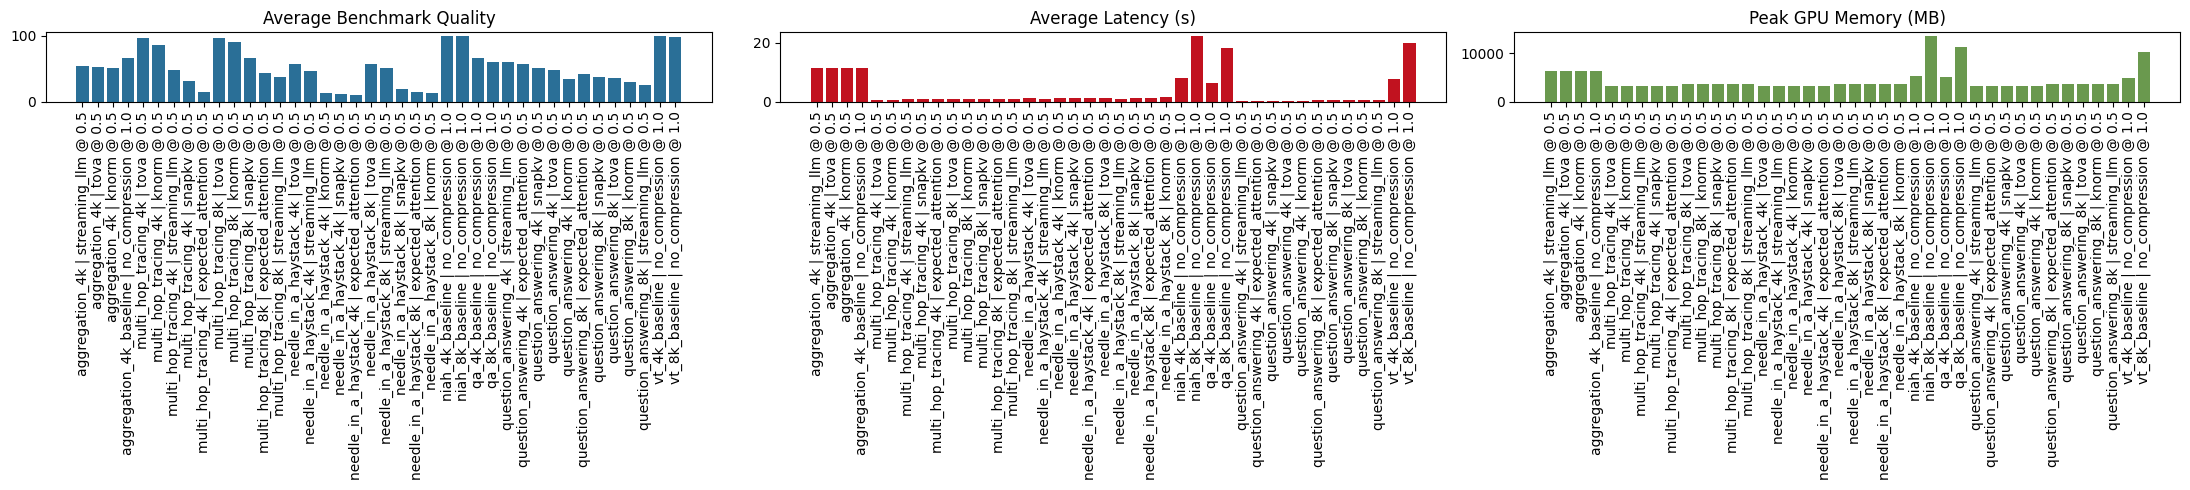

In [9]:
# Presentation plots.
import matplotlib.pyplot as plt

if 'leaderboard' in globals() and not leaderboard.empty:
    plot_df = leaderboard.copy()
    plot_df['label'] = plot_df['scenario_name'] + ' | ' + plot_df['method'] + ' @ ' + plot_df['budget'].astype(str)
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))
    axes[0].bar(plot_df['label'], plot_df['avg_quality'], color='#2a6f97')
    axes[0].set_title('Average Benchmark Quality')
    axes[0].tick_params(axis='x', rotation=90)
    axes[1].bar(plot_df['label'], plot_df['avg_latency_seconds'], color='#c1121f')
    axes[1].set_title('Average Latency (s)')
    axes[1].tick_params(axis='x', rotation=90)
    axes[2].bar(plot_df['label'], plot_df['peak_gpu_memory_mb'], color='#6a994e')
    axes[2].set_title('Peak GPU Memory (MB)')
    axes[2].tick_params(axis='x', rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print('Leaderboard not ready yet.')


In [10]:
# Simple recommendation table.
import pandas as pd

if 'leaderboard' in globals() and not leaderboard.empty:
    best_quality = leaderboard.sort_values(['avg_quality', 'avg_latency_seconds'], ascending=[False, True]).iloc[0]
    best_latency = leaderboard.sort_values('avg_latency_seconds', ascending=True).iloc[0]
    best_memory = leaderboard.dropna(subset=['peak_gpu_memory_mb']).sort_values('peak_gpu_memory_mb', ascending=True).iloc[0]
    recommendations = pd.DataFrame([
        {'category': 'best_for_quality', 'scenario_name': best_quality['scenario_name'], 'method': best_quality['method'], 'budget': best_quality['budget']},
        {'category': 'best_for_latency', 'scenario_name': best_latency['scenario_name'], 'method': best_latency['method'], 'budget': best_latency['budget']},
        {'category': 'best_for_memory', 'scenario_name': best_memory['scenario_name'], 'method': best_memory['method'], 'budget': best_memory['budget']},
    ])
    display(recommendations)
else:
    print('Leaderboard not ready yet.')


,category,scenario_name,method,budget
0,best_for_quality,vt_4k_baseline,no_compression,1.0
1,best_for_latency,question_answering_4k,streaming_llm,0.5
2,best_for_memory,multi_hop_tracing_4k,knorm,0.5


In [ ]:
# Optional smoke test: one tiny benchmark-backed slice to verify the environment.
!python scripts/run_kvpress_benchmark_eval.py   --dataset ruler   --data-dir 4096   --model Qwen/Qwen2.5-1.5B-Instruct   --method no_compression   --budget 1.0   --fraction 0.002   --torch-dtype bfloat16   --output-dir "$SHARED_RESULTS_DIR/benchmark_eval"


## Granular Task-Level Analysis

This section focuses on dissecting the `metrics.json` files to extract individual task performance, allowing for a deeper understanding of how different KV Cache strategies perform on specific sub-tasks.

In [11]:
import json
import pandas as pd
from pathlib import Path

if 'combined_summary' in globals() and not combined_summary.empty:
    task_metrics_data = []

    for index, row in combined_summary.iterrows():
        metrics_path = Path(row['metrics_path'])
        if metrics_path.exists():
            with open(metrics_path, 'r', encoding='utf-8') as f:
                metrics = json.load(f)

            # Extract task-specific metrics
            for task_prefix, task_results in metrics.items():
                # Flatten task_results if there are multiple metrics per task (e.g., {'string_match': 0.8, 'exact_match': 0.7})
                for metric_name, metric_value in task_results.items():
                    task_metrics_data.append({
                        'scenario_name': row['scenario_name'],
                        'dataset': row['dataset'],
                        'data_dir': row['data_dir'],
                        'task_prefix': task_prefix, # Original task prefix like 'niah', 'qa', 'cwe', 'fwe'
                        'method': row['method'],
                        'budget': row['budget'],
                        'metric_name': metric_name,
                        'metric_value': metric_value
                    })

    if task_metrics_data:
        granular_df = pd.DataFrame(task_metrics_data)
        print("### Head of Granular Task-Level Metrics DataFrame:")
        display(granular_df.head())

        print("\n### Unique Metrics Found:")
        print(granular_df['metric_name'].unique())

        print("\n### Unique Task Prefixes Found:")
        print(granular_df['task_prefix'].unique())

    else:
        print('No task-level metrics could be loaded.')
else:
    print('Combined summary not available. Please run the aggregation cells first.')

### Head of Granular Task-Level Metrics DataFrame:


,scenario_name,dataset,data_dir,task_prefix,method,budget,metric_name,metric_value
0,needle_in_a_haystack_4k,ruler,4096,niah_multikey_1,snapkv,0.5,string_match,10.00
1,needle_in_a_haystack_4k,ruler,4096,niah_multikey_2,snapkv,0.5,string_match,25.00
2,needle_in_a_haystack_4k,ruler,4096,niah_multikey_3,snapkv,0.5,string_match,4.00
3,needle_in_a_haystack_4k,ruler,4096,niah_multiquery,snapkv,0.5,string_match,6.58
4,needle_in_a_haystack_4k,ruler,4096,niah_multivalue,snapkv,0.5,string_match,16.67



### Unique Metrics Found:
['string_match']

### Unique Task Prefixes Found:
['niah_multikey_1' 'niah_multikey_2' 'niah_multikey_3' 'niah_multiquery'
 'niah_multivalue' 'niah_single_1' 'niah_single_2' 'niah_single_3' 'qa_1'
 'qa_2' 'vt' 'cwe' 'fwe']


### Next Steps for Granular Analysis:

Now that we have the `granular_df` DataFrame containing task-level metrics, we can:

1.  **Filter and Group**: Select specific `task_prefix` values (e.g., 'niah', 'qa') and group by `method` to compare their performance on those specific tasks.
2.  **Visualize**: Create plots (e.g., bar plots, box plots) to visualize the `metric_value` for different methods on a given `task_prefix`.
3.  **Identify Strengths**: Look for methods that consistently perform better (higher `metric_value`) on certain `task_prefix` types. This will help in formulating recommendations.

### Visualizing Granular Task Performance

Below are comparative plots for each unique task prefix found in the data, showing the `metric_value` (e.g., string match score) for each KV Cache method. This detailed view helps in pinpointing which strategies excel in particular sub-tasks.

### Analyzing Task Prefix: niah_multikey_1


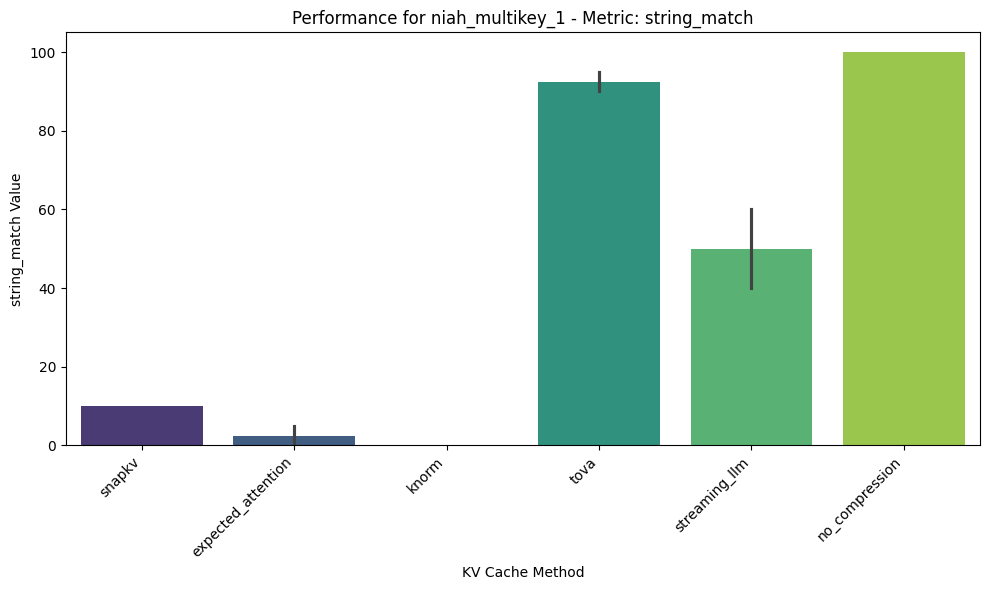


----------------------------------------------------------------------------------------------------

### Analyzing Task Prefix: niah_multikey_2


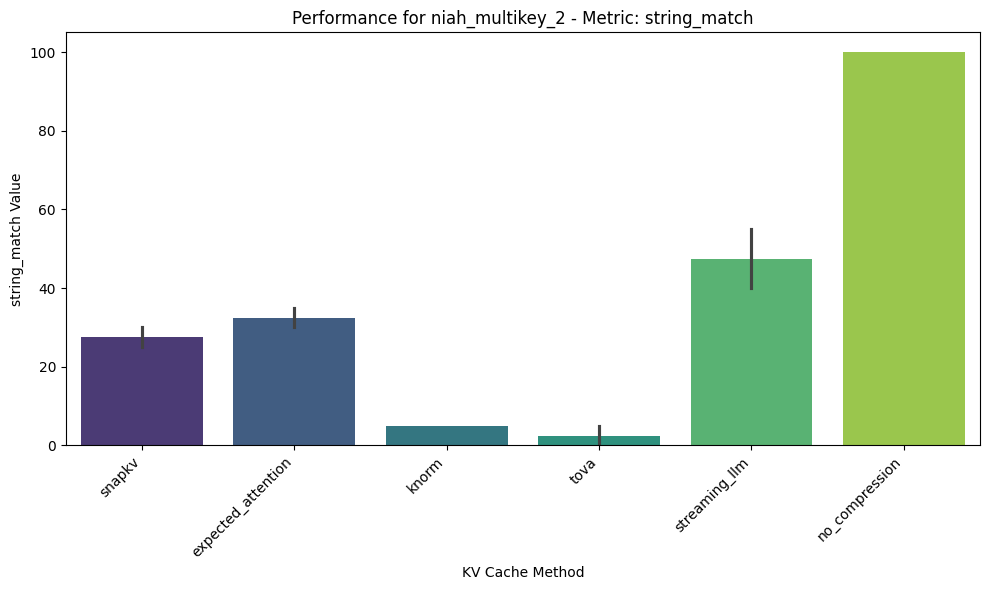


----------------------------------------------------------------------------------------------------

### Analyzing Task Prefix: niah_multikey_3


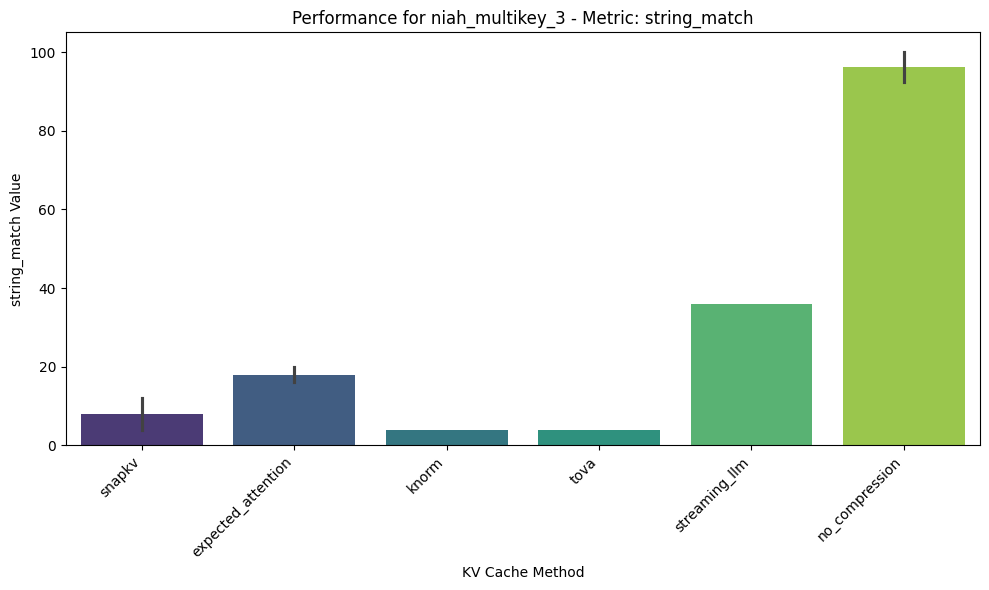


----------------------------------------------------------------------------------------------------

### Analyzing Task Prefix: niah_multiquery


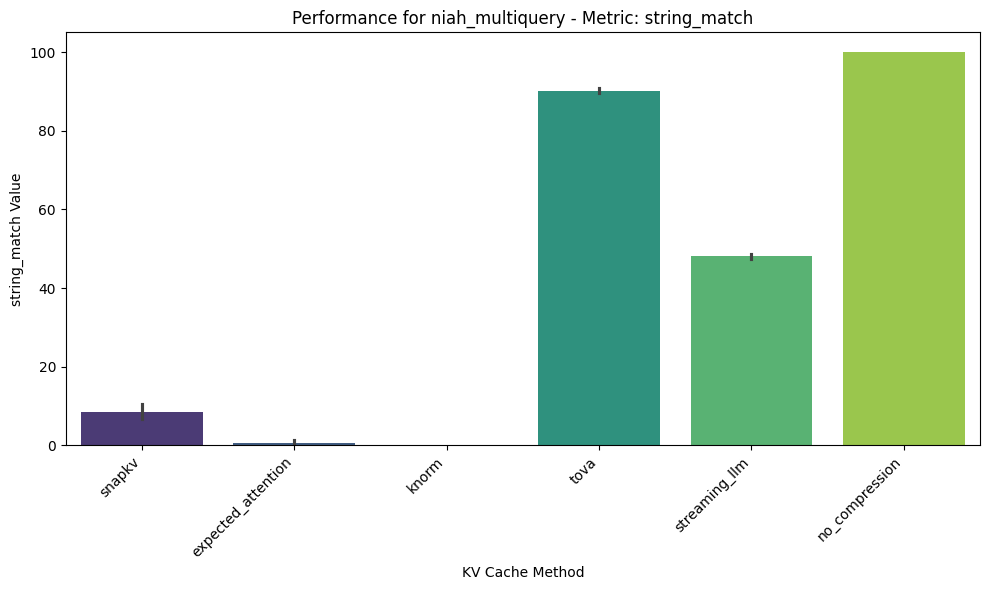


----------------------------------------------------------------------------------------------------

### Analyzing Task Prefix: niah_multivalue


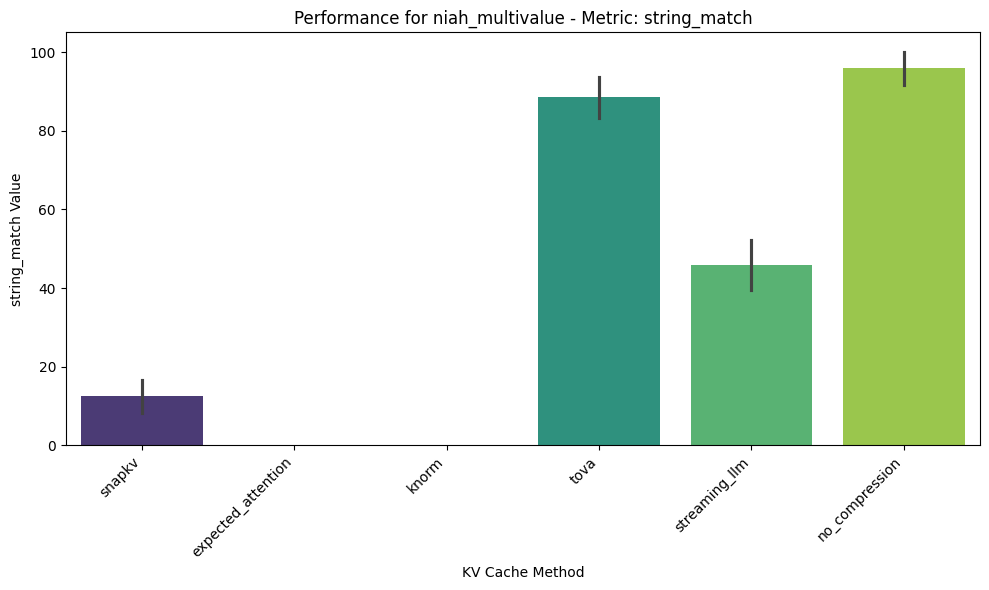


----------------------------------------------------------------------------------------------------

### Analyzing Task Prefix: niah_single_1


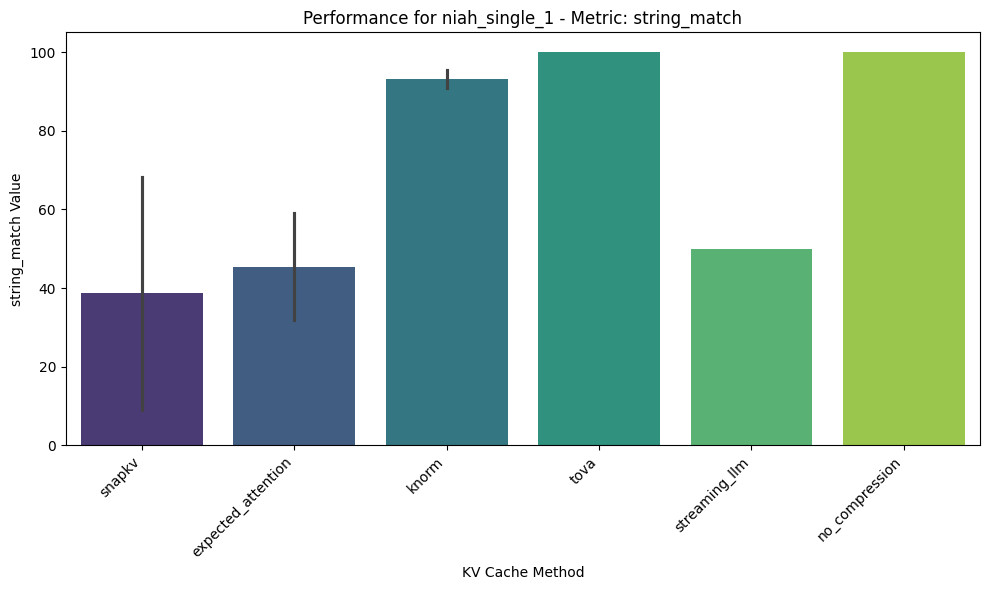


----------------------------------------------------------------------------------------------------

### Analyzing Task Prefix: niah_single_2


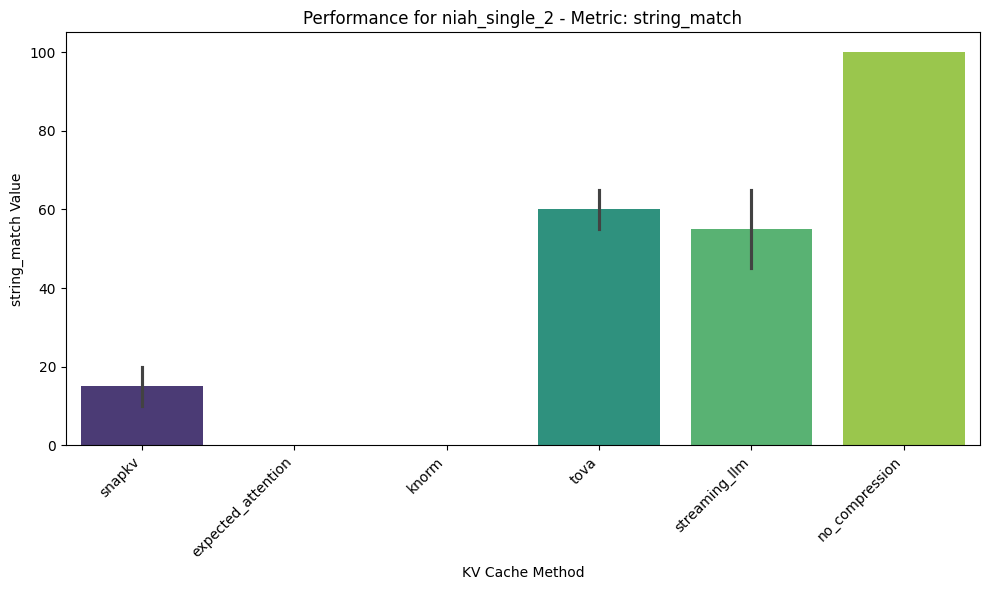


----------------------------------------------------------------------------------------------------

### Analyzing Task Prefix: niah_single_3


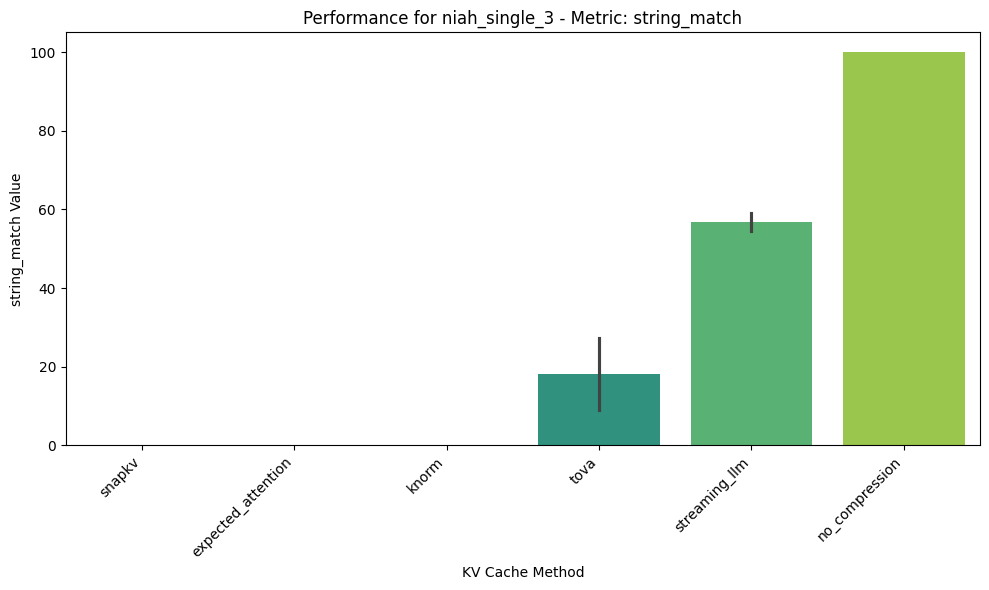


----------------------------------------------------------------------------------------------------

### Analyzing Task Prefix: qa_1


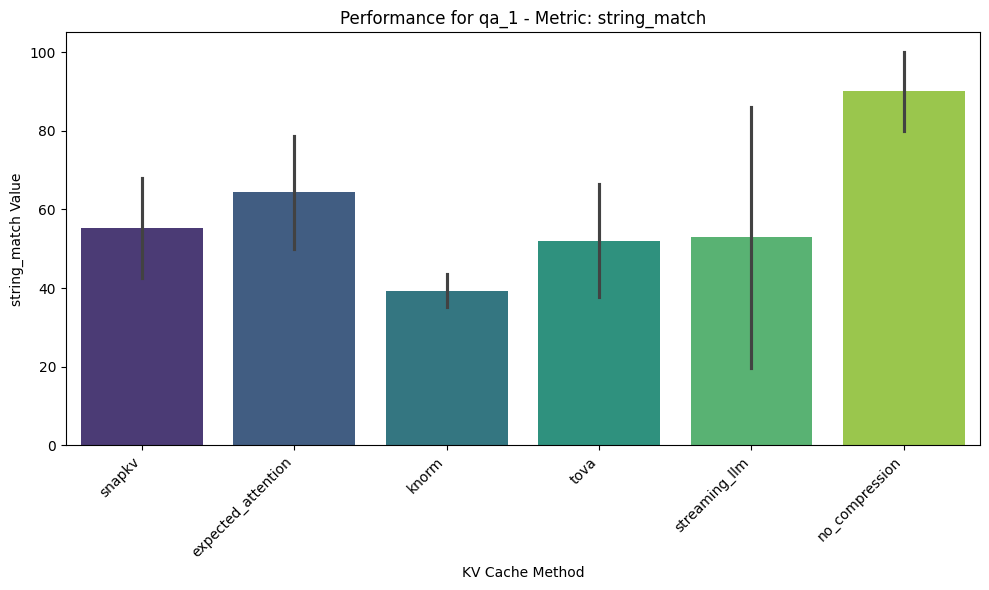


----------------------------------------------------------------------------------------------------

### Analyzing Task Prefix: qa_2


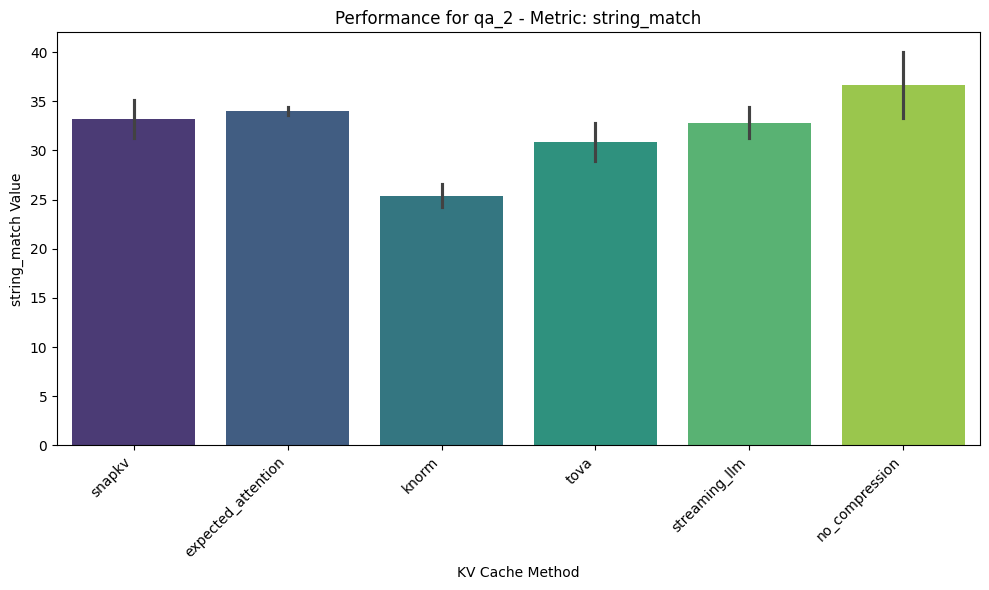


----------------------------------------------------------------------------------------------------

### Analyzing Task Prefix: vt


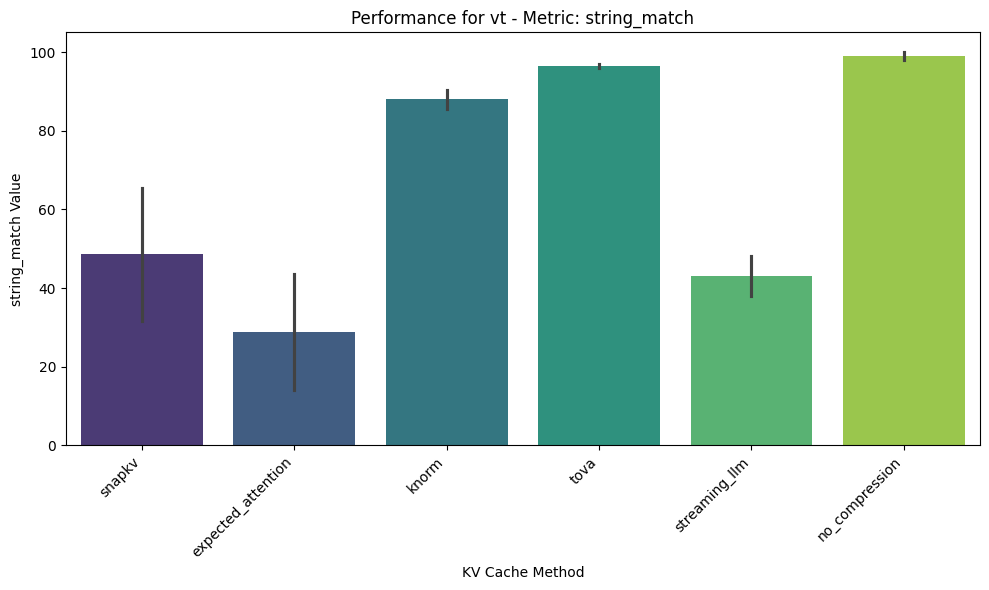


----------------------------------------------------------------------------------------------------

### Analyzing Task Prefix: cwe


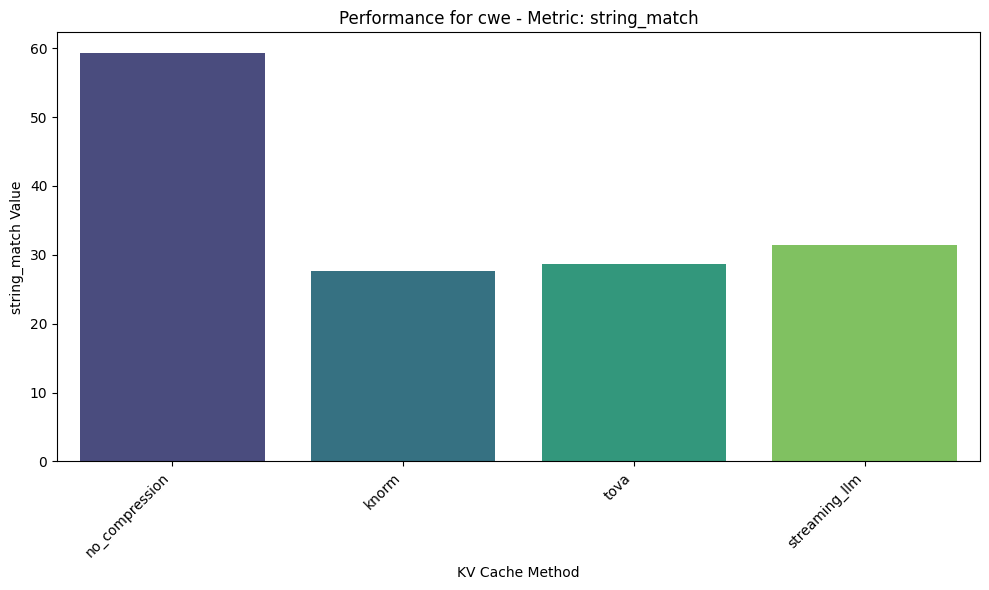


----------------------------------------------------------------------------------------------------

### Analyzing Task Prefix: fwe


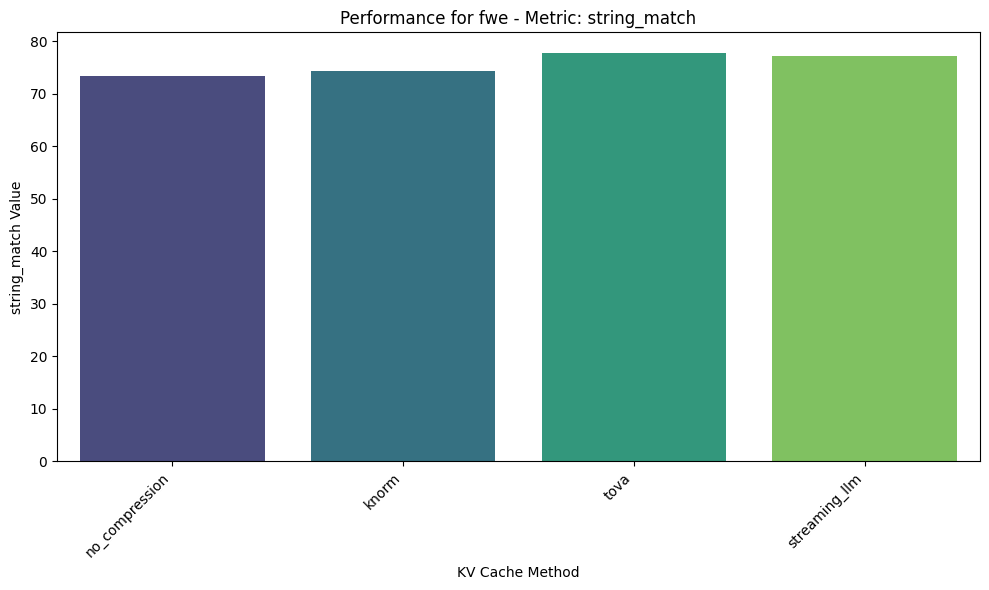


----------------------------------------------------------------------------------------------------



In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'granular_df' in globals() and not granular_df.empty:
    unique_task_prefixes = granular_df['task_prefix'].unique()
    unique_metrics = granular_df['metric_name'].unique()

    # Iterate through each unique task prefix
    for task_prefix in unique_task_prefixes:
        print(f"### Analyzing Task Prefix: {task_prefix}")
        task_prefix_df = granular_df[granular_df['task_prefix'] == task_prefix].copy()

        # Iterate through each unique metric for this task prefix
        for metric in unique_metrics:
            metric_df = task_prefix_df[task_prefix_df['metric_name'] == metric].copy()

            if not metric_df.empty:
                plt.figure(figsize=(10, 6))
                sns.barplot(x='method', y='metric_value', data=metric_df,
                            palette='viridis', hue='method', legend=False)
                plt.title(f'Performance for {task_prefix} - Metric: {metric}')
                plt.xlabel('KV Cache Method')
                plt.ylabel(f'{metric} Value')
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                plt.show()
            else:
                print(f"No data for metric '{metric}' in task prefix '{task_prefix}'.")
        print("\n" + "-"*100 + "\n") # Separator for readability

else:
    print('Granular DataFrame not available. Please ensure the previous cells generating granular_df have been run.')

### Aggregated Analysis for Main Task Categories

This section provides an aggregated view of the performance for each KV Cache method across the four main task categories: Needle In A Haystack, Question Answering, Multi-Hop Tracing, and Aggregation.

In [13]:
import numpy as np

if 'granular_df' in globals() and not granular_df.empty:
    # Define mapping from granular task prefixes to main task categories
    task_category_map = {
        'niah': 'Needle In A Haystack',
        'qa': 'Question Answering',
        'vt': 'Multi-Hop Tracing',
        'cwe': 'Aggregation',
        'fwe': 'Aggregation',
    }

    # Function to apply the mapping (handles variations like 'niah_multikey_1')
    def get_main_task_category(task_prefix):
        for key, category in task_category_map.items():
            if task_prefix.startswith(key):
                return category
        return 'Other' # Fallback for any unmapped prefixes

    # Apply the mapping to create a new 'main_task_category' column
    granular_df['main_task_category'] = granular_df['task_prefix'].apply(get_main_task_category)

    # Aggregate by main_task_category, method, and metric_name
    aggregated_main_tasks_df = granular_df.groupby(['main_task_category', 'method', 'metric_name'])['metric_value'].mean().reset_index()

    print("### Aggregated Metrics per Main Task Category:")
    display(aggregated_main_tasks_df.head())

else:
    print('Granular DataFrame not available. Please ensure the previous cells generating granular_df have been run.')

### Aggregated Metrics per Main Task Category:


,main_task_category,method,metric_name,metric_value
0,Aggregation,knorm,string_match,51.000
1,Aggregation,no_compression,string_match,66.330
2,Aggregation,streaming_llm,string_match,54.215
3,Aggregation,tova,string_match,53.215
4,Multi-Hop Tracing,expected_attention,string_match,28.880


### Visualizing Main Task Category: Aggregation


/tmp/ipykernel_9651/2214327148.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')


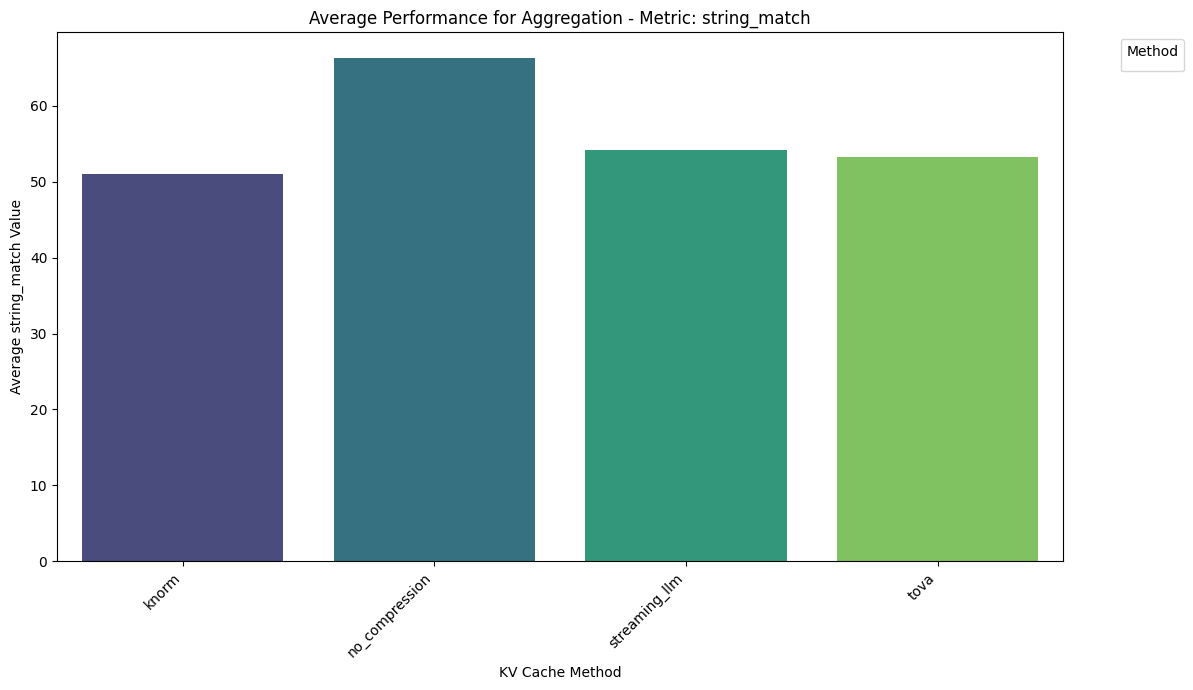


----------------------------------------------------------------------------------------------------

### Visualizing Main Task Category: Multi-Hop Tracing


/tmp/ipykernel_9651/2214327148.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')


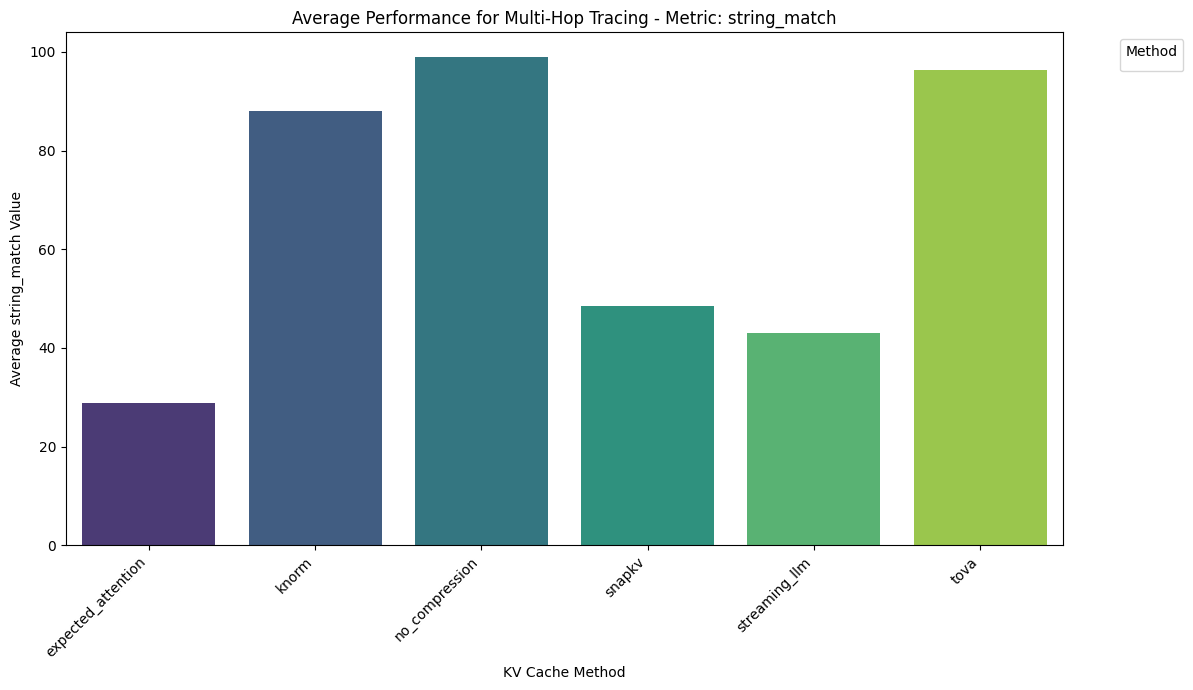


----------------------------------------------------------------------------------------------------

### Visualizing Main Task Category: Needle In A Haystack


/tmp/ipykernel_9651/2214327148.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')


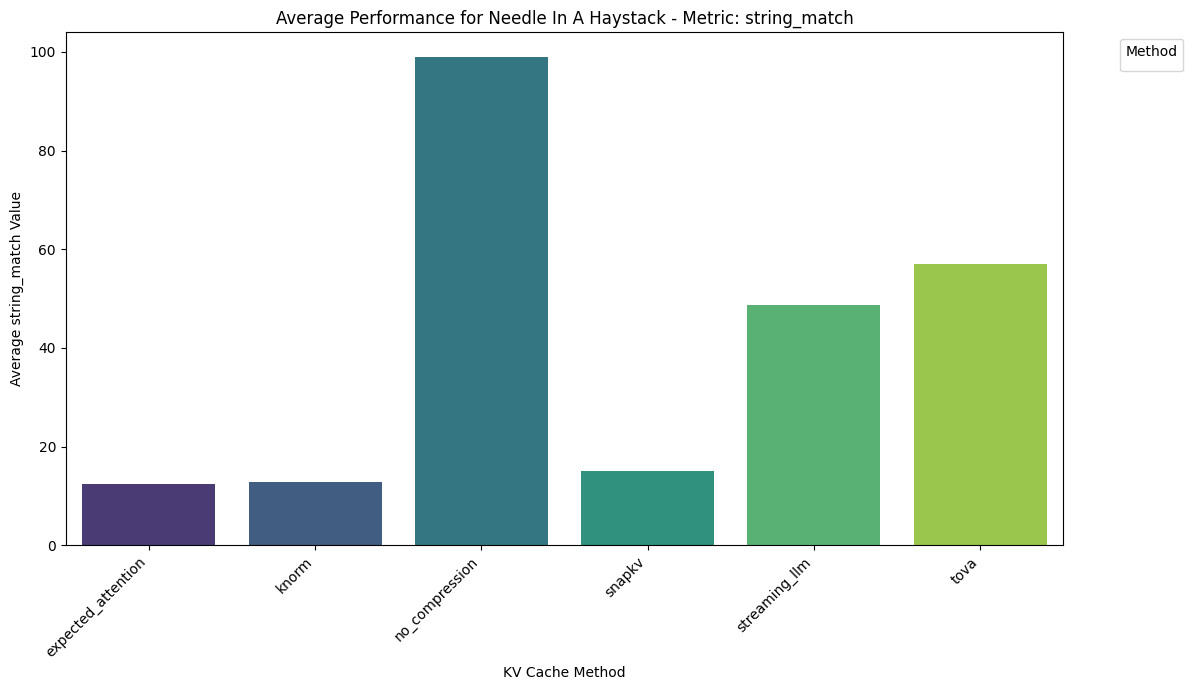


----------------------------------------------------------------------------------------------------

### Visualizing Main Task Category: Question Answering


/tmp/ipykernel_9651/2214327148.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')


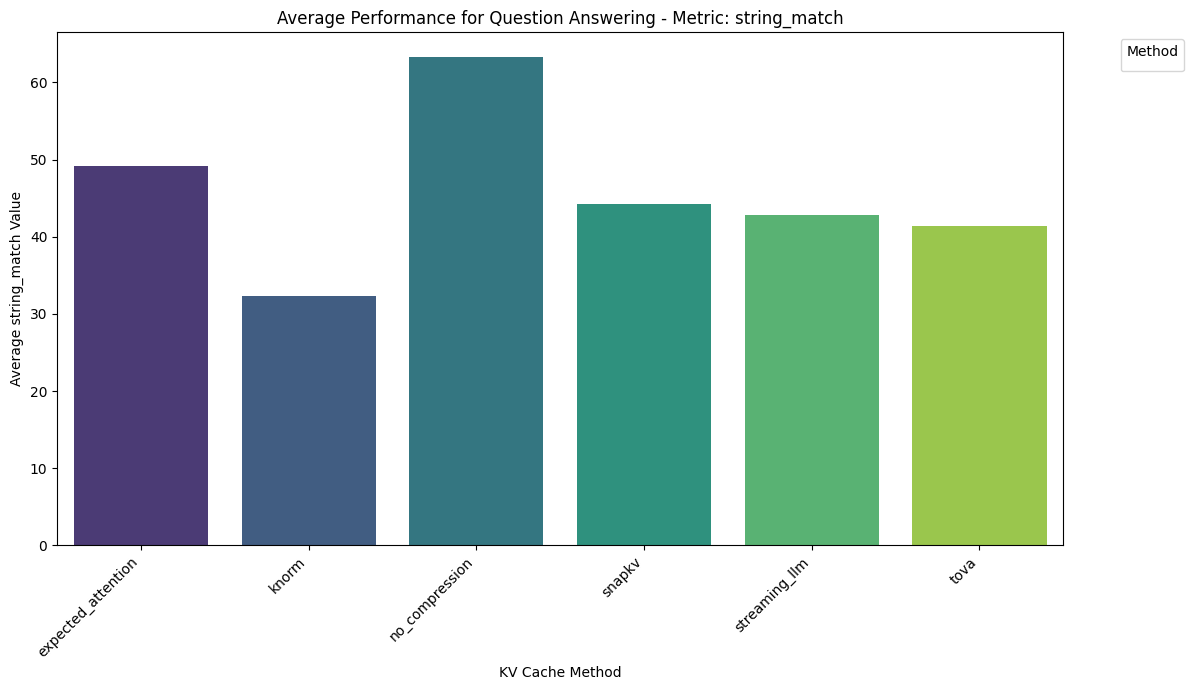


----------------------------------------------------------------------------------------------------



In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'aggregated_main_tasks_df' in globals() and not aggregated_main_tasks_df.empty:
    unique_main_task_categories = aggregated_main_tasks_df['main_task_category'].unique()
    unique_metrics = aggregated_main_tasks_df['metric_name'].unique()

    for main_category in unique_main_task_categories:
        print(f"### Visualizing Main Task Category: {main_category}")
        category_df = aggregated_main_tasks_df[aggregated_main_tasks_df['main_task_category'] == main_category].copy()

        for metric in unique_metrics:
            metric_category_df = category_df[category_df['metric_name'] == metric].copy()

            if not metric_category_df.empty:
                plt.figure(figsize=(12, 7))
                sns.barplot(x='method', y='metric_value', data=metric_category_df,
                            palette='viridis', hue='method')
                plt.title(f'Average Performance for {main_category} - Metric: {metric}')
                plt.xlabel('KV Cache Method')
                plt.ylabel(f'Average {metric} Value')
                plt.xticks(rotation=45, ha='right')
                plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
                plt.tight_layout()
                plt.show()
            else:
                print(f"No data for metric '{metric}' in main task category '{main_category}'.")
        print("\n" + "-"*100 + "\n") # Separator for readability
else:
    print('Aggregated main tasks DataFrame not available. Please ensure the previous cells have been run.')